## Quais fatores explicam a taxa de criminalidade?

### Instalando Pacotes

In [7]:
import pandas as pd
import  numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem Estatistica

import pylab
import scipy
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.regression.linear_model as smf
import statsmodels.stats.api as sms
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.compat import lzip
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_goldfeldquandt
from sklearn.metrics import (mean_squared_error, mean_absolute_error,r2_score)

# Divisão de Dados

import sklearn
from sklearn.model_selection import train_test_split

# Padronização de Dados

from sklearn.preprocessing import StandardScaler


### Carregando Dados

In [8]:
import pandas as pd

df = pd.read_csv("../data/dataset.csv")

In [9]:
df.head()

,numero_medio_quartos_por_residencia,idade_media_residencias,taxa_criminalidade,proporcao_lotes,proporcao_empresas,rio_no_bairro,taxa_poluicao,distancia_centro,index_acessibilidade,imposto_residencial,taxa_professores,consumo_medio_energia,taxa_desabrigados,taxa_ocupacao
0,6.575,65.2,0.00634,18.0,2.31,0,0.538,4.0900,1,296,15.3,396.90,4.98,24.0
1,6.421,78.9,0.02731,0.0,7.07,0,0.469,4.9671,2,242,17.8,396.90,9.14,21.6
2,7.185,61.1,0.02729,0.0,7.07,0,0.469,4.9671,2,242,17.8,392.83,4.03,34.7
3,6.998,45.8,0.03237,0.0,2.18,0,0.458,6.0622,3,222,18.7,394.63,2.94,33.4
4,7.147,54.2,0.06905,0.0,2.18,0,0.458,6.0622,3,222,18.7,396.90,5.33,36.2


In [10]:
dados = df.copy()

### Analise Exploratoria

In [11]:
dados.shape

(500, 14)

In [12]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   numero_medio_quartos_por_residencia  500 non-null    float64
 1   idade_media_residencias              500 non-null    float64
 2   taxa_criminalidade                   500 non-null    float64
 3   proporcao_lotes                      500 non-null    float64
 4   proporcao_empresas                   500 non-null    float64
 5   rio_no_bairro                        500 non-null    int64  
 6   taxa_poluicao                        500 non-null    float64
 7   distancia_centro                     500 non-null    float64
 8   index_acessibilidade                 500 non-null    int64  
 9   imposto_residencial                  500 non-null    int64  
 10  taxa_professores                     500 non-null    float64
 11  consumo_medio_energia           

In [13]:
dados.describe()

,numero_medio_quartos_por_residencia,idade_media_residencias,taxa_criminalidade,proporcao_lotes,proporcao_empresas,rio_no_bairro,taxa_poluicao,distancia_centro,index_acessibilidade,imposto_residencial,taxa_professores,consumo_medio_energia,taxa_desabrigados,taxa_ocupacao
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,6.282970,68.424600,3.655786,11.500000,11.131740,0.070000,0.554451,3.811932,9.642000,409.624000,18.428600,356.208040,12.698740,22.568000
std,0.705421,28.272145,8.644375,23.428739,6.900712,0.255403,0.116550,2.112591,8.715604,168.998579,2.162553,91.741874,7.164928,9.235707
min,3.561000,2.900000,0.006340,0.000000,0.460000,0.000000,0.385000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,5.883000,44.225000,0.082598,0.000000,5.130000,0.000000,0.448750,2.087875,4.000000,281.000000,17.225000,375.085000,6.990000,17.075000
50%,6.208500,77.150000,0.266005,0.000000,9.125000,0.000000,0.538000,3.267450,5.000000,330.000000,19.000000,391.305000,11.430000,21.200000
75%,6.620500,94.100000,3.694070,12.500000,18.100000,0.000000,0.624000,5.214600,24.000000,666.000000,20.200000,396.157500,17.092500,25.000000
max,8.780000,100.000000,88.976200,100.000000,27.740000,1.000000,0.871000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


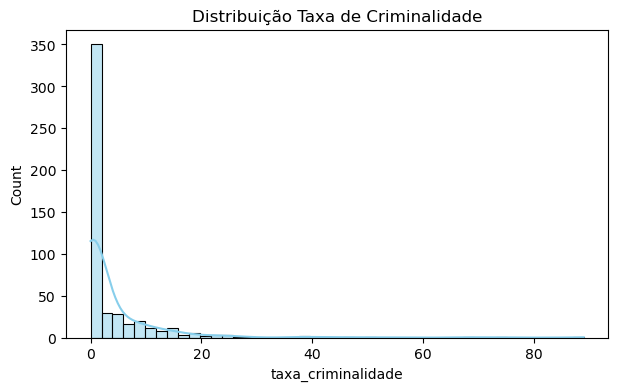

In [14]:
# Variavel Alvo e sua Distribuição

plt.figure(figsize=(7,4))
sns.histplot(data = dados, x = dados.taxa_criminalidade, kde=True, color="skyblue" )
plt.title("Distribuição Taxa de Criminalidade")
plt.show()

Identificado uam Distribuição Assimetrica a direita o usaremos Skew para verificar sua Assimetria

In [15]:
dados.skew()

numero_medio_quartos_por_residencia    0.408139
idade_media_residencias               -0.584415
taxa_criminalidade                     5.194110
proporcao_lotes                        2.205864
proporcao_empresas                     0.295577
rio_no_bairro                          3.380756
taxa_poluicao                          0.731641
distancia_centro                       0.993597
index_acessibilidade                   0.991658
imposto_residencial                    0.652944
taxa_professores                      -0.793662
consumo_medio_energia                 -2.868339
taxa_desabrigados                      0.893201
taxa_ocupacao                          1.099558
dtype: float64

Identificado Assimetria na varivael Alvo 'Taxa_Criminalidade' de 5.19411. Faremos aplicação de Log para verificar possivel normalização , e em seguida geração do Grafico de Distribuição da Variavel Alva Normalizada 'log_taxa_criminalidade'

In [16]:
dados['log_taxa_criminalidade']=np.log(dados['taxa_criminalidade'])

In [17]:
dados.skew()

numero_medio_quartos_por_residencia    0.408139
idade_media_residencias               -0.584415
taxa_criminalidade                     5.194110
proporcao_lotes                        2.205864
proporcao_empresas                     0.295577
rio_no_bairro                          3.380756
taxa_poluicao                          0.731641
distancia_centro                       0.993597
index_acessibilidade                   0.991658
imposto_residencial                    0.652944
taxa_professores                      -0.793662
consumo_medio_energia                 -2.868339
taxa_desabrigados                      0.893201
taxa_ocupacao                          1.099558
log_taxa_criminalidade                 0.387845
dtype: float64

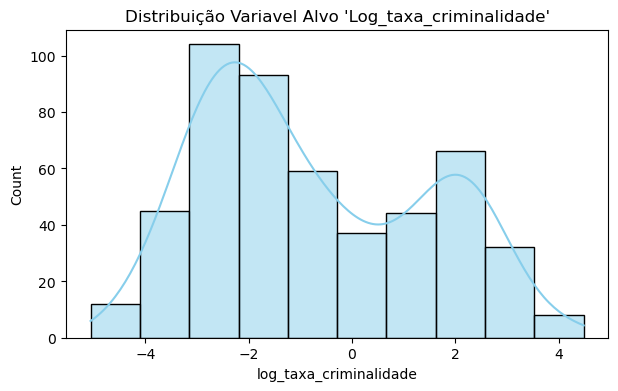

In [18]:
plt.figure(figsize = (7,4))
sns.histplot(data = dados, x= dados['log_taxa_criminalidade'], kde=True, color="skyblue")
plt.title("Distribuição Variavel Alvo 'Log_taxa_criminalidade'")
plt.show()

In [19]:
dados.corr()

,numero_medio_quartos_por_residencia,idade_media_residencias,taxa_criminalidade,proporcao_lotes,proporcao_empresas,rio_no_bairro,taxa_poluicao,distancia_centro,index_acessibilidade,imposto_residencial,taxa_professores,consumo_medio_energia,taxa_desabrigados,taxa_ocupacao,log_taxa_criminalidade
numero_medio_quartos_por_residencia,1.000000,-0.243044,-0.218919,0.314221,-0.393012,0.092122,-0.303151,0.208031,-0.208559,-0.291159,-0.362163,0.127517,-0.613654,0.696424,-0.306837
idade_media_residencias,-0.243044,1.000000,0.355852,-0.568654,0.645526,0.088155,0.731859,-0.747426,0.463883,0.512673,0.258119,-0.276578,0.608452,-0.376758,0.666669
taxa_criminalidade,-0.218919,0.355852,1.000000,-0.203363,0.407351,-0.057316,0.422339,-0.384391,0.624880,0.581835,0.297472,-0.383776,0.454628,-0.390960,0.666076
proporcao_lotes,0.314221,-0.568654,-0.203363,1.000000,-0.534292,-0.044375,-0.516414,0.663235,-0.319191,-0.320072,-0.388901,0.178462,-0.417814,0.359733,-0.525068
proporcao_empresas,-0.393012,0.645526,0.407351,-0.534292,1.000000,0.063174,0.763810,-0.709502,0.599156,0.724065,0.384794,-0.357710,0.606354,-0.484606,0.735163
rio_no_bairro,0.092122,0.088155,-0.057316,-0.044375,0.063174,1.000000,0.091835,-0.101685,-0.010326,-0.037972,-0.119013,0.050259,-0.055847,0.174606,0.025914
taxa_poluicao,-0.303151,0.731859,0.422339,-0.516414,0.763810,0.091835,1.000000,-0.770068,0.616414,0.671652,0.188255,-0.381440,0.593524,-0.427432,0.794011
distancia_centro,0.208031,-0.747426,-0.384391,0.663235,-0.709502,-0.101685,-0.770068,1.000000,-0.505664,-0.543241,-0.226258,0.296059,-0.504135,0.248688,-0.693636
index_acessibilidade,-0.208559,0.463883,0.624880,-0.319191,0.599156,-0.010326,0.616414,-0.505664,1.000000,0.909742,0.482377,-0.442594,0.485830,-0.387305,0.852128
imposto_residencial,-0.291159,0.512673,0.581835,-0.320072,0.724065,-0.037972,0.671652,-0.543241,0.909742,1.000000,0.475243,-0.440226,0.541711,-0.473117,0.827132


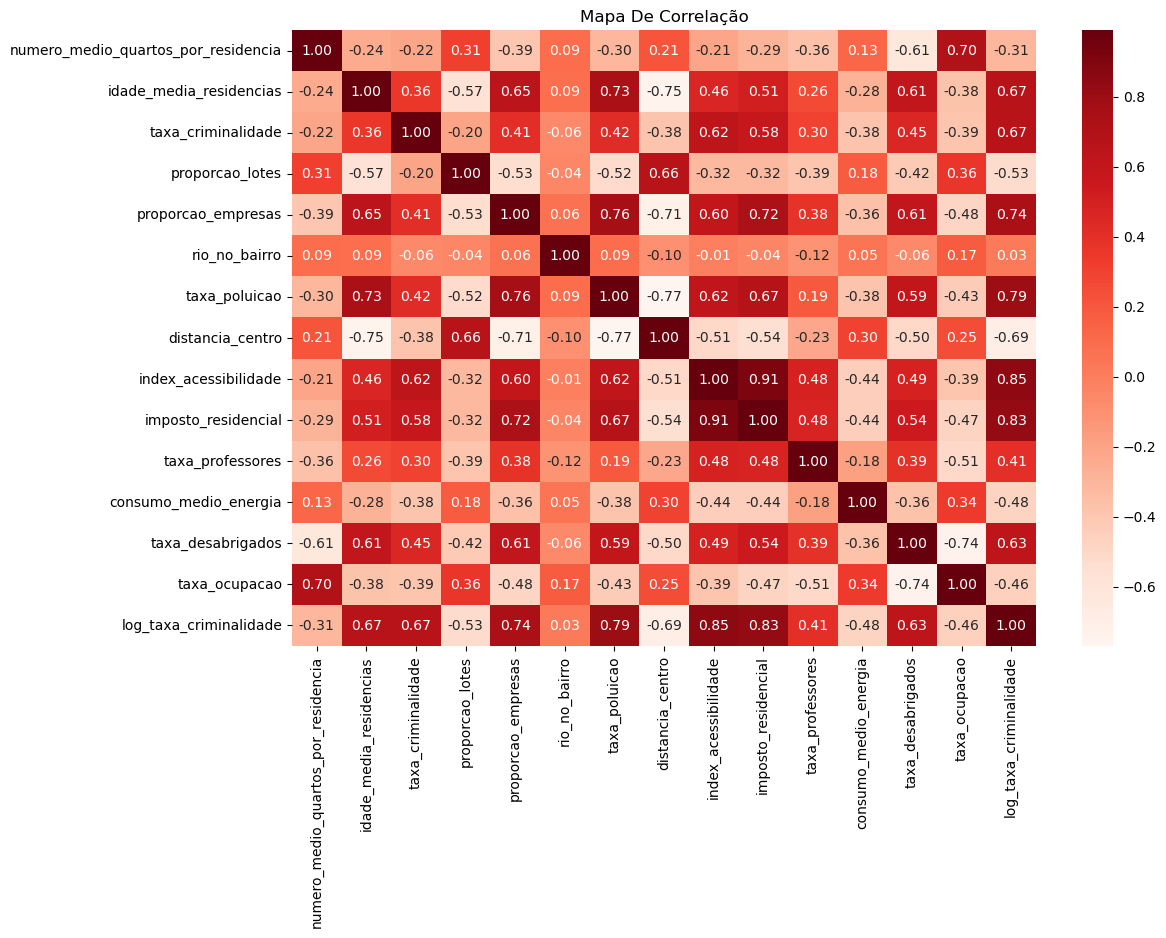

In [20]:
# Gerando o Grafico de correlção com a Variavelo alvo

plt.figure(figsize=(12,8))
sns.heatmap(dados.corr(), annot = True, fmt ='.2f', cmap = 'Reds', vmax = .99,)
plt.title("Mapa De Correlação")
plt.show()

Identificado que algumas variaveis tem grande diferença entre valor minimos, maximos podendo indicar a presença de Outliers e descarcterizando uma Distribuição Normal. Iremos analisar essas variaveis a parte.

In [21]:
### Analise Bivariada

*Analisaremos de maneira a parte as variaveis independentes  com correlação maior que 0.70 positva ou negativa entre si*

[]

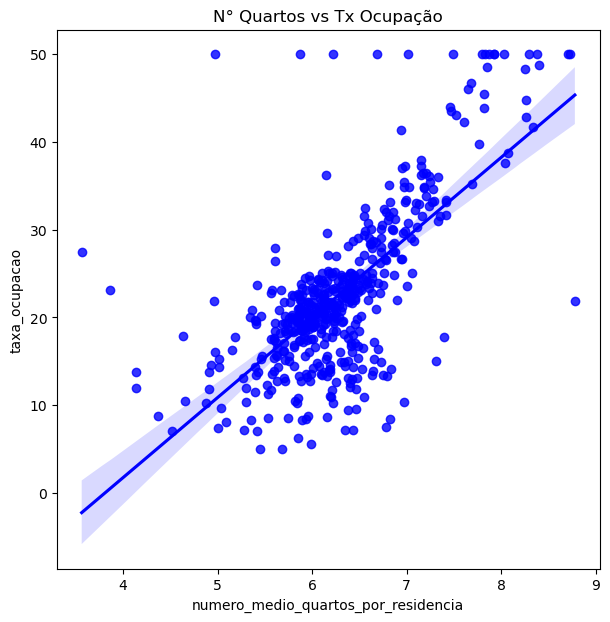

In [22]:
# N° Qartos vs Tx Ocupação
plt.figure(figsize=(7,7))
sns.regplot(x='numero_medio_quartos_por_residencia', y='taxa_ocupacao', data=dados, color='blue' )
plt.title("N° Quartos vs Tx Ocupação")
plt.plot()

In [23]:
print('A Correlação entre as variaveis é:', pearsonr(dados['numero_medio_quartos_por_residencia'],
                                                    dados['taxa_ocupacao'])[0])

A Correlação entre as variaveis é: 0.696423826484379


Correlação Positiva entre as variaveis Qto maior o numero medio de Quartos por residencia maior o indice de ocupação do Imóvel , possivel presença de outliers nos dados.

[]

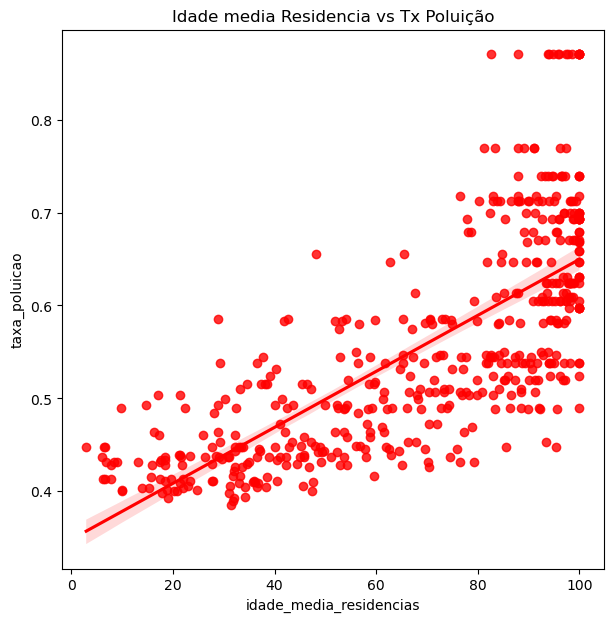

In [24]:
# Idade media Residencia vs Tx Poluição

plt.figure(figsize=(7,7))
sns.regplot(x='idade_media_residencias', y='taxa_poluicao', data=dados, color='red' )
plt.title("Idade media Residencia vs Tx Poluição")
plt.plot()

Identificado possiveis Outliers nos dados, percebe-se uma relação positiva entre as variaveis quanto maior a idade do imovel(quanto mais velho) maior a taxa de poluição.

In [25]:
print('A Correlação entre as variaveis é:', pearsonr(dados['idade_media_residencias'],
                                                    dados['taxa_poluicao'])[0])

A Correlação entre as variaveis é: 0.7318586310142243


[]

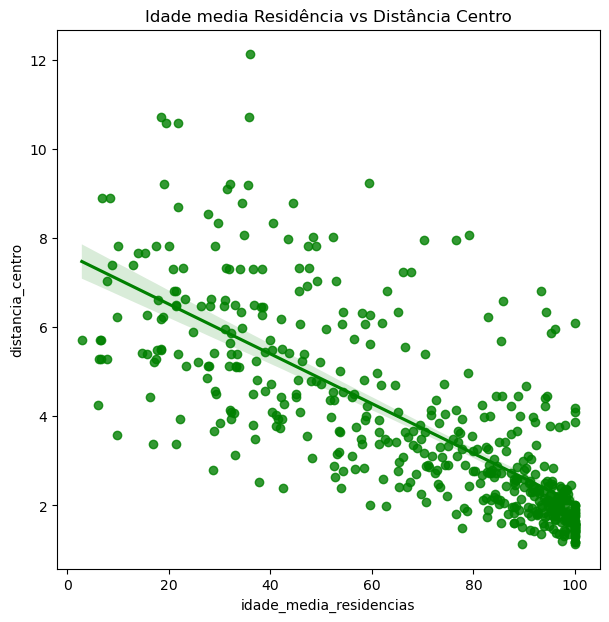

In [26]:
# Idade media Residencia vs Distancia Centro
plt.figure(figsize=(7,7))
sns.regplot(x='idade_media_residencias', y='distancia_centro', data=dados, color='green' )
plt.title("Idade media Residência vs Distância Centro")
plt.plot()


In [27]:
print('A Correlação entre as variaveis é:', pearsonr(dados['idade_media_residencias'],
                                                    dados['distancia_centro'])[0])

A Correlação entre as variaveis é: -0.7474258681640551


O Grafico Mostra que quanto mais novo o imovel mais longe ele é do Centro, forte correlação negativa entre as variaveis

[]

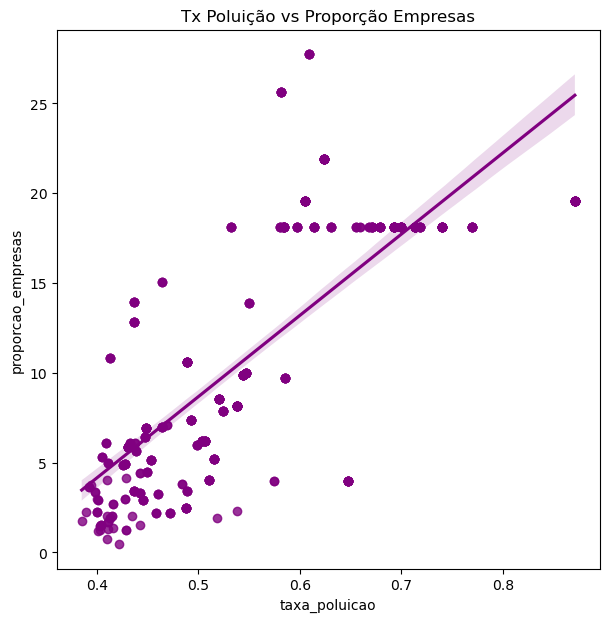

In [28]:
# Tx Poluição vs Proporção Empresas
plt.figure(figsize=(7,7))
sns.regplot(x='taxa_poluicao', y='proporcao_empresas', data=dados, color='purple' )
plt.title("Tx Poluição vs Proporção Empresas")
plt.plot()

In [29]:
print('A Correlação entre as variaveis é:', pearsonr(dados['taxa_poluicao'],
                                                    dados['proporcao_empresas'])[0])

A Correlação entre as variaveis é: 0.7638104350783939


Correlação Positiva entre as variaveis percebe-se que quanto mais empresas maiores são as tx de poluição presentes

[]

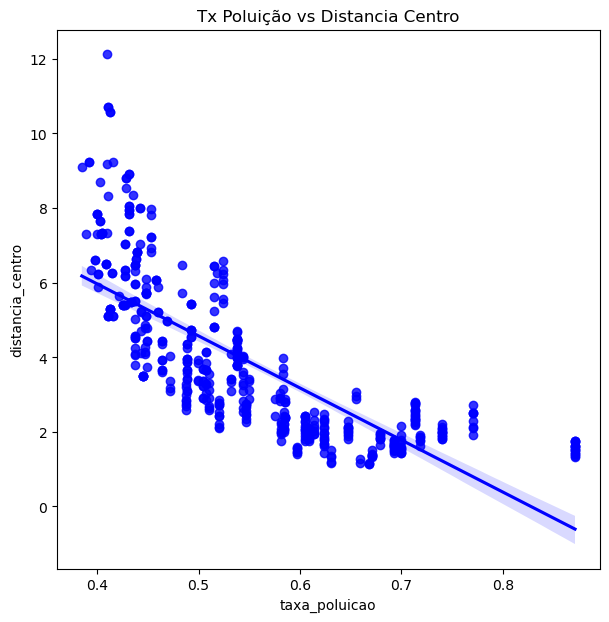

In [30]:
# Tx Poluição vs Distancia Centro
plt.figure(figsize=(7,7))
sns.regplot(x='taxa_poluicao', y='distancia_centro', data=dados, color='blue' )
plt.title("Tx Poluição vs Distancia Centro")
plt.plot()

In [31]:
print('A Correlação entre as variaveis é:', pearsonr(dados['taxa_poluicao'],
                                                    dados['distancia_centro'])[0])

A Correlação entre as variaveis é: -0.7700682232177494


Correlação Negativa entre as veriaveis quanto mais longe do Centro menor a tx de poluição

[]

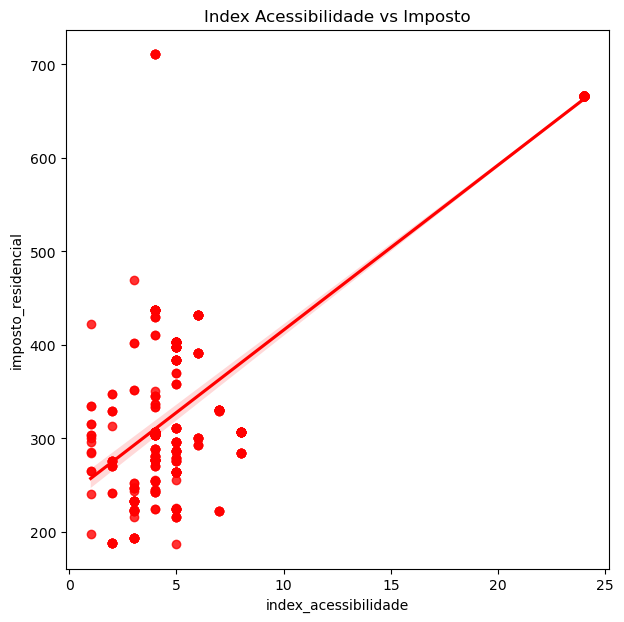

In [32]:
# Index Acessibilidade vs Imposto

plt.figure(figsize=(7,7))
sns.regplot(x='index_acessibilidade', y='imposto_residencial', data=dados, color='red' )
plt.title("Index Acessibilidade vs Imposto")
plt.plot()

In [33]:
print('A Correlação entre as variaveis é:', pearsonr(dados['index_acessibilidade'],
                                                    dados['imposto_residencial'])[0])

A Correlação entre as variaveis é: 0.9097418944674467


Correlçao Muita alta proximo de 1 e concentração de dados proximo a 10, constatação de Outliers nos dados

[]

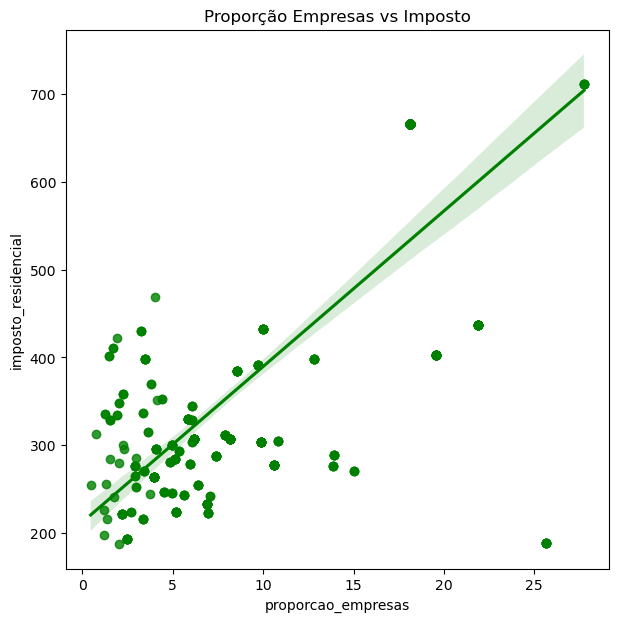

In [34]:
# Proporção Empresas vs Imposto

plt.figure(figsize=(7,7))
sns.regplot(x='proporcao_empresas', y='imposto_residencial', data=dados, color='green' )
plt.title("Proporção Empresas vs Imposto")
plt.plot()

In [35]:
print('A Correlação entre as variaveis é:', pearsonr(dados['proporcao_empresas'],
                                                    dados['imposto_residencial'])[0])

A Correlação entre as variaveis é: 0.7240653150756319


Correlação Positiva entre as variaveis quanto maior a proporção de empresas maior o Imposto Residencial, no entando esta correlação pode estar sendo afetada por um 3 elemento

[]

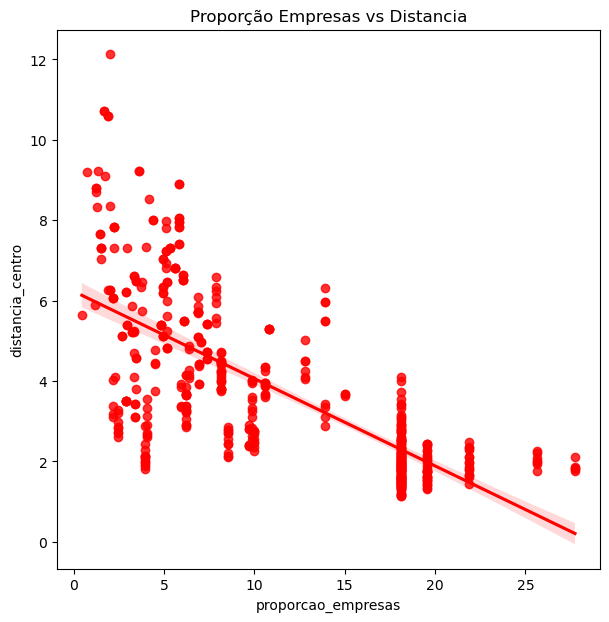

In [36]:
# Proporção Empresas vs Distancia 

plt.figure(figsize=(7,7))
sns.regplot(x='proporcao_empresas', y='distancia_centro', data=dados, color='red' )
plt.title("Proporção Empresas vs Distancia")
plt.plot()

In [37]:
print('A Correlação entre as variaveis é:', pearsonr(dados['proporcao_empresas'],
                                                    dados['distancia_centro'])[0])

A Correlação entre as variaveis é: -0.7095021817163114


Correlação Negativa entre as variaves quanto maior a distancia do centro menor a proporção de Empresas presentes

[]

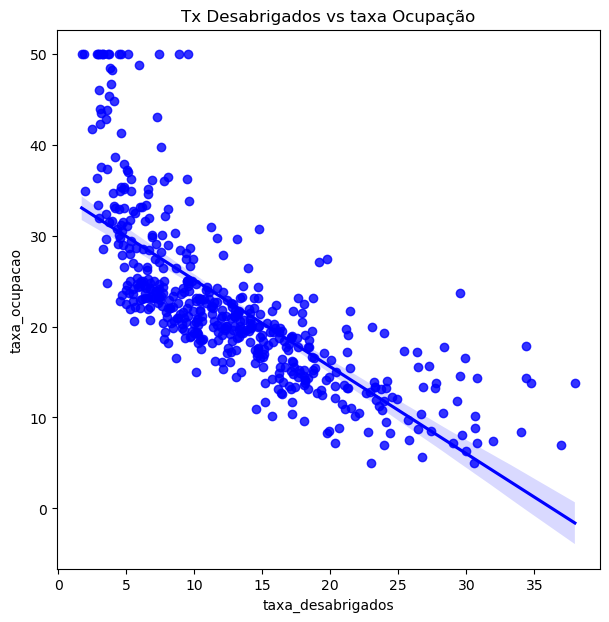

In [38]:
# Tx Desabrigados vs taxa Ocupação

plt.figure(figsize=(7,7))
sns.regplot(x='taxa_desabrigados', y='taxa_ocupacao', data=dados, color='blue' )
plt.title("Tx Desabrigados vs taxa Ocupação")
plt.plot()

In [39]:
print('A Correlação entre as variaveis é:', pearsonr(dados['taxa_desabrigados'],
                                                    dados['taxa_ocupacao'])[0])

A Correlação entre as variaveis é: -0.7422362776461563


Forte Correlação Negativa quanto Maior a taxa de Ocupação menor o numero de Desabrigados 

### Preparação dos Dados

In [40]:
# Separando as Variaveis 
Y = dados['log_taxa_criminalidade']
X= dados.drop(columns= {'log_taxa_criminalidade', 'taxa_criminalidade'})

In [41]:
# Divisão em Treino e teste

X_treino, X_teste, y_treino,y_teste = train_test_split(X,Y,test_size=0.20,random_state=1)

In [42]:
# Confirmando Divisão dos Dados
print(f"Dados Treinos(X): {X_treino.shape}")
print(f"Dados Treinos(Y): {y_treino.shape}")
print(f"\nDados Test(X): {X_teste.shape}")
print(f"Dados Test(Y): {y_teste.shape}")

Dados Treinos(X): (400, 13)
Dados Treinos(Y): (400,)

Dados Test(X): (100, 13)
Dados Test(Y): (100,)


### Modelagem Estatistica - Versão 1 Modelo

In [43]:
# Adicionando Contante

X_treino_cost = sm.add_constant(X_treino)

In [44]:
modelo_v1 = sm.OLS(y_treino,X_treino_cost).fit()

In [45]:
modelo_v1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     log_taxa_criminalidade   R-squared:                       0.878
Model:                                OLS   Adj. R-squared:                  0.874
Method:                     Least Squares   F-statistic:                     214.3
Date:                    Mon, 08 Jun 2026   Prob (F-statistic):          2.06e-167
Time:                            16:26:47   Log-Likelihood:                -454.41
No. Observations:                     400   AIC:                             936.8
Df Residuals:                         386   BIC:                             992.7
Df Model:                              13                                         
Covariance Type:                nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -4.5683      0.972     -4.700      0.000      -6.479      -2.657
numero_medio_quartos_por_residencia     0.0025      0.084      0.030      0.976      -0.162       0.167
idade_media_residencias                 0.0051      0.002      2.098      0.037       0.000       0.010
proporcao_lotes                        -0.0119      0.003     -4.691      0.000      -0.017      -0.007
proporcao_empresas                      0.0102      0.011      0.923      0.356      -0.011       0.032
rio_no_bairro                          -0.0833      0.150     -0.556      0.578      -0.378       0.211
taxa_poluicao                           4.1947      0.699      6.002      0.000       2.821       5.569
distancia_centro                       -0.0068      0.038     -0.181      0.857      -0.081       0.067
index_acessibilidade                    0.1310      0.012     10.657      0.000       0.107       0.155
imposto_residencial                     0.0006      0.001      0.773      0.440      -0.001       0.002
taxa_professores                       -0.0224      0.025     -0.879      0.380      -0.072       0.028
consumo_medio_energia                  -0.0013      0.000     -2.740      0.006      -0.002      -0.000
taxa_desabrigados                       0.0313      0.011      2.979      0.003       0.011       0.052
taxa_ocupacao                           0.0078      0.008      0.978      0.329      -0.008       0.023
==============================================================================
Omnibus:                        1.877   Durbin-Watson:                   1.955
Prob(Omnibus):                  0.391   Jarque-Bera (JB):                1.940
Skew:                           0.162   Prob(JB):                        0.379
Kurtosis:                       2.892   Cond. No.                     1.58e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.58e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### R-Squad de 0.87 o que demostra que o modelo consegue interpretar bem a relação entre as variaveis preditoras e a variavel alvo, no entanto temos um Note alegando que os dados podem contem Multicolineariedade que iremos resolver agora.

### Um dos fatores para a Multicolineariedade pode ser não padronização Supossição essa da Regressão Linear que foi deixada de lado de maneira proposital para reforçar o aprendizado simulando o cenario real do profissional Cientista de Dados.

## _Verificando Multicolinearidade com VIF_

In [46]:
def verifica_vif(train):
    # Calcula VIF para cada variável
    vif = pd.DataFrame()
    vif["feature"] = train.columns
    vif["VIF"] = [variance_inflation_factor(train.values, i) for i in range(train.shape[1])]

    return vif

In [47]:
print(verifica_vif(X_treino))

                                feature         VIF
0   numero_medio_quartos_por_residencia  135.314304
1               idade_media_residencias   22.013716
2                       proporcao_lotes    3.045765
3                    proporcao_empresas   14.247986
4                         rio_no_bairro    1.181963
5                         taxa_poluicao   72.328120
6                      distancia_centro   15.571328
7                  index_acessibilidade   15.909262
8                   imposto_residencial   67.450186
9                      taxa_professores   90.638494
10                consumo_medio_energia   21.131274
11                    taxa_desabrigados   13.471518
12                        taxa_ocupacao   23.980666


VIF = 1 → sem correlação com outras variáveis.

VIF entre 1 e 5 → correlação moderada, geralmente aceitável.

VIF > 10 → multicolinearidade severa, recomenda-se remover ou transformar variáveis.

### No nosso caso as variaveis em suma maioria esta com valores acima do indice VIF assim com  alta multicolinearidade. Vamos aplicar normalização nos dados a seguir.

### Padronização dos Dados

In [48]:
scaler = StandardScaler()

In [49]:
X_treino_scaled = scaler.fit_transform(X_treino)

In [50]:
X_treino_scaled.shape

(400, 13)

In [51]:
X_teste_scaled = scaler.transform(X_teste)

In [52]:
X_teste.shape

(100, 13)

In [53]:
# DataFrame padronizado com os nomes corretos das features

df_X_treino = pd.DataFrame(
    X_treino_scaled,
    columns=[
        'numero_medio_quartos_por_residencia',
        'idade_media_residencias',
        'proporcao_lotes',
        'proporcao_empresas',
        'rio_no_bairro',
        'taxa_poluicao',
        'distancia_centro',
        'index_acessibilidade',
        'imposto_residencial',
        'taxa_professores',
        'consumo_medio_energia',
        'taxa_desabrigados',
        'taxa_ocupacao'
    ]
)



In [54]:
# Convertemos o array de teste em dataframe de teste
df_X_teste = pd.DataFrame(
    X_teste_scaled,
    columns=[
        'numero_medio_quartos_por_residencia',
        'idade_media_residencias',
        'proporcao_lotes',
        'proporcao_empresas',
        'rio_no_bairro',
        'taxa_poluicao',
        'distancia_centro',
        'index_acessibilidade',
        'imposto_residencial',
        'taxa_professores',
        'consumo_medio_energia',
        'taxa_desabrigados',
        'taxa_ocupacao'
    ]
)


### Modelagem Estatistica - Versão 2 Modelo

In [55]:
# Adciona a Constante

X_treino_cost = sm.add_constant(X_treino_scaled)

In [56]:
modelo_v2 = sm.OLS(y_treino,X_treino_cost).fit()

In [57]:
modelo_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     log_taxa_criminalidade   R-squared:                       0.878
Model:                                OLS   Adj. R-squared:                  0.874
Method:                     Least Squares   F-statistic:                     214.3
Date:                    Mon, 08 Jun 2026   Prob (F-statistic):          2.06e-167
Time:                            16:26:48   Log-Likelihood:                -454.41
No. Observations:                     400   AIC:                             936.8
Df Residuals:                         386   BIC:                             992.7
Df Model:                              13                                         
Covariance Type:                nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7499      0.038    -19.551      0.000      -0.825      -0.674
x1             0.0018      0.059      0.030      0.976      -0.114       0.117
x2             0.1446      0.069      2.098      0.037       0.009       0.280
x3            -0.2820      0.060     -4.691      0.000      -0.400      -0.164
x4             0.0701      0.076      0.923      0.356      -0.079       0.219
x5            -0.0223      0.040     -0.556      0.578      -0.101       0.056
x6             0.4932      0.082      6.002      0.000       0.332       0.655
x7            -0.0146      0.081     -0.181      0.857      -0.173       0.144
x8             1.1464      0.108     10.657      0.000       0.935       1.358
x9             0.0943      0.122      0.773      0.440      -0.145       0.334
x10           -0.0483      0.055     -0.879      0.380      -0.156       0.060
x11           -0.1215      0.044     -2.740      0.006      -0.209      -0.034
x12            0.2231      0.075      2.979      0.003       0.076       0.370
x13            0.0731      0.075      0.978      0.329      -0.074       0.220
==============================================================================
Omnibus:                        1.877   Durbin-Watson:                   1.955
Prob(Omnibus):                  0.391   Jarque-Bera (JB):                1.940
Skew:                           0.162   Prob(JB):                        0.379
Kurtosis:                       2.892   Cond. No.                         10.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

O R-squared: manteve identico ao 1° Modelo porém dessa vez já não temos problemas de multicolinearidade no Modelo. No entanto temos alguns variaveis com valor > p acima de 0.05 o que pode ser indicio de  que essas variavis não estão contribuindo para o modelo. 

Removeremos : 
x1,x4,x5,x7,x9,x10 e x13

In [58]:
# Removendo as colunas de Indice 

X_Treino_clean = np.delete(X_treino_scaled, [0,3,4,6,8,9,12], axis= 1)
X_Teste_clean = np.delete(X_teste_scaled, [0,3,4,6,8,9,12], axis= 1)

In [59]:
X_Treino_clean.shape

(400, 6)

In [60]:
X_Teste_clean.shape

(100, 6)

In [61]:
y_treino.shape

(400,)

In [62]:
# Removendo colunas com multicolinearidade

del df_X_treino['numero_medio_quartos_por_residencia']
del df_X_treino['proporcao_empresas']
del df_X_treino['rio_no_bairro']
del df_X_treino['distancia_centro']
del df_X_treino['imposto_residencial']
del df_X_treino['taxa_professores']
del df_X_treino['taxa_ocupacao']


del df_X_teste['numero_medio_quartos_por_residencia']
del df_X_teste['proporcao_empresas']
del df_X_teste['rio_no_bairro']
del df_X_teste['distancia_centro']
del df_X_teste['imposto_residencial']
del df_X_teste['taxa_professores']
del df_X_teste['taxa_ocupacao']

### Modelagem Estatistica - Versão 3 Modelo

In [63]:
# Adiciona a Contante 

X_treino_cost = sm.add_constant(X_Treino_clean)

In [64]:
modelo_v3 = sm.OLS(y_treino,X_treino_cost).fit()

In [65]:
modelo_v3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     log_taxa_criminalidade   R-squared:                       0.877
Model:                                OLS   Adj. R-squared:                  0.875
Method:                     Least Squares   F-statistic:                     465.8
Date:                    Mon, 08 Jun 2026   Prob (F-statistic):          3.47e-175
Time:                            16:26:48   Log-Likelihood:                -456.97
No. Observations:                     400   AIC:                             927.9
Df Residuals:                         393   BIC:                             955.9
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7499      0.038    -19.602      0.000      -0.825      -0.675
x1             0.1708      0.063      2.720      0.007       0.047       0.294
x2            -0.2664      0.048     -5.570      0.000      -0.360      -0.172
x3             0.5597      0.065      8.661      0.000       0.433       0.687
x4             1.2058      0.051     23.566      0.000       1.105       1.306
x5            -0.1239      0.044     -2.842      0.005      -0.210      -0.038
x6             0.1727      0.052      3.337      0.001       0.071       0.274
==============================================================================
Omnibus:                        1.050   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.592   Jarque-Bera (JB):                1.122
Skew:                           0.119   Prob(JB):                        0.571
Kurtosis:                       2.897   Cond. No.                         3.82
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Nosso 3 Modelo demosntrou que consegue compreender bem a correlção entre a variavel alvo e as variaveis preditoras, sendo assim podemos para a proxima etapa Validar as Suposições da Regressão Linear antes de usar o modelo.

Principais suposições a validar:

. Linearidade

. Independência dos erros

. Homoscedasticidade (variância constante dos erros)

. Normalidade dos Erros

. Ausência de multicolinearidade



### Linearidade - Método Raimbown

In [66]:
rainbown = sms.linear_rainbow(modelo_v3,frac= 0.5)[1]

if rainbown >= 0.05:
    print("Como o valor-p foi superior a 0,05, não rejeita-se a hipótese nula (H0),\nindicando que o modelo linear é adequado para representar a relação entre as variáveis.")
else:
    print(" Como o valor-p foi inferior ou igual a 0,05, rejeita-se a hipótese nula (H0), \nindicando evidências de não-linearidade na relação entre as variáveis.")
    
print(rainbown)

Como o valor-p foi superior a 0,05, não rejeita-se a hipótese nula (H0),
indicando que o modelo linear é adequado para representar a relação entre as variáveis.
0.5701166666937254


### Indepêndencia dos Erros - Durbin–Watson

In [67]:
residual = modelo_v3.resid

In [68]:


def valida_residuos(residuos):
    import statsmodels
    
    resultado = statsmodels.stats.stattools.durbin_watson(residuos)

    print('Resultado do Teste:' , resultado)

    if resultado < 1.9:

        print('Há evidências de autocorrelação positiva nos erros. Suposição não atendida!!')

    elif resultado > 2.1:

        print('Há evidências de autocorrelação negativa nos erros.  Suposição não atendida!!')

    else:

        print('Não há evidências de autocorrelação nos erros. Suposição atendida! ')



In [69]:
valida_residuos(residual)

Resultado do Teste: 1.9453528382341927
Não há evidências de autocorrelação nos erros. Suposição atendida! 


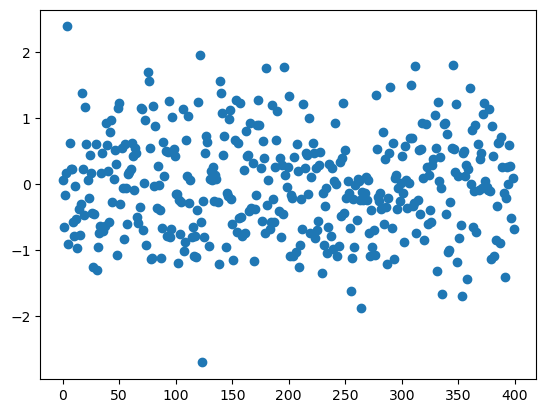

In [70]:
plt.scatter(range(len(X_treino_cost)),residual)

*O teste de Durbin–Watson apresentou estatística igual a 1.94, valor próximo de 2, indicando ausência de autocorrelação significativa nos resíduos e sugerindo independência dos erros do modelo de regressão linear.*

### Homocedasticidade - Breusch–Pagan

In [71]:
def breusch(modelo):
    teste = het_breuschpagan(modelo.resid,modelo.model.exog)
    pvalor= teste[1]
    print("Método Breusch–Pagan")
    print(f'Valor-p: {pvalor:.4f}')
    if pvalor >= 0.05:
        print('\nOs resíduos são homocedásticos.')
    else:
        print('\nHá evidências de heterocedasticidade.')

In [72]:
breusch(modelo_v3)

Método Breusch–Pagan
Valor-p: 0.0016

Há evidências de heterocedasticidade.


In [73]:
def goldfeld(modelo):
    
    teste = het_goldfeldquandt(modelo.model.endog,modelo.model.exog)
    pvalor= teste[1]
    print("Método Goldfeld–Quandt")
    print(f'Valor-p: {pvalor:.4f}')
    if pvalor >= 0.05:
        print('\nOs resíduos são homocedásticos.')
    else:
        print('\nHá evidências de heterocedasticidade.')


In [74]:
goldfeld(modelo_v3)

Método Goldfeld–Quandt
Valor-p: 0.8456

Os resíduos são homocedásticos.


### Como Ambos as análises geraram resultados diferentes iremos fazer uso de um grafico para dar suporte à decisão.

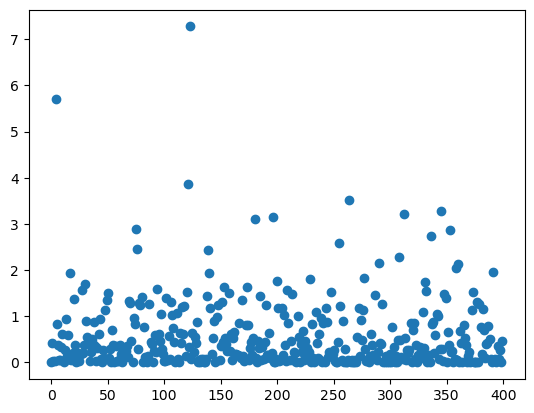

In [75]:
plt.scatter(range(len(X_Treino_clean)),np.square(residual));

A análise gráfica dos resíduos não evidenciou padrões claros de heterocedasticidade, apresentando dispersão aproximadamente constante ao longo das observações. Além disso, o teste de Goldfeld–Quandt apresentou valor-p igual a 0,84, não indicando evidências de variância não constante dos resíduos. Embora o teste de Breusch–Pagan tenha identificado heterocedasticidade estatisticamente significativa em nível de 5%, os resultados visuais e complementares sugerem que tal efeito é relativamente sutil no modelo analisado.


### Normalização Dos Erros : Shapiro–Wilk.

In [76]:
def teste_shapiro(residuos):
    from scipy.stats import shapiro
    resultado = shapiro(residuos)
    pvalor= resultado.pvalue

    print("Método Shapiro–Wilk")
    print(f'Valor-p: {pvalor:.4f}')
    if pvalor >= 0.05:
        print('\nOs resíduos seguem distribuição normal.')
    else:
        print('\nOs resíduos não seguem distribuição normal.')


In [77]:
teste_shapiro(modelo_v3.resid)

Método Shapiro–Wilk
Valor-p: 0.1525

Os resíduos seguem distribuição normal.


O teste de Shapiro–Wilk apresentou valor-p igual a 0,1525, superior ao nível 
de significância de 5%. Dessa forma, não foram encontradas evidências para rejeitar
a hipótese nula de normalidade, indicando que os resíduos do modelo podem
ser considerados aproximadamente normais.


In [78]:
residuals = modelo_v3.resid

<Axes: ylabel='Count'>

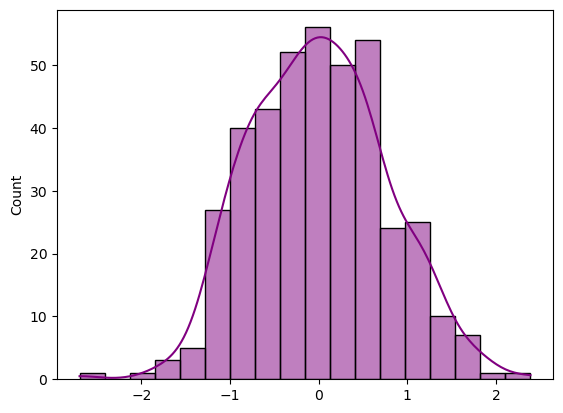

In [79]:
sns.histplot(residuals, kde= True, color ='purple')

### Multicolinearidade : VIF

In [80]:
def verifica_vif(train):
    # Calcula VIF para cada variável
    vif = pd.DataFrame()
    vif["feature"] = train.columns
    vif["VIF"] = [variance_inflation_factor(train.values, i) for i in range(train.shape[1])]

    return vif

In [81]:
print(verifica_vif(df_X_treino))

                   feature       VIF
0  idade_media_residencias  2.694229
1          proporcao_lotes  1.562279
2            taxa_poluicao  2.853335
3     index_acessibilidade  1.788837
4    consumo_medio_energia  1.299743
5        taxa_desabrigados  1.830873


A multicolinearidade entre as variáveis explicativas foi avaliada por meio do Fator de Inflação da Variância (VIF). Após a remoção das variáveis com elevada correlação linear, todos os preditores remanescentes apresentaram valores de VIF inferiores a 5, indicando ausência de multicolinearidade significativa no modelo final.


**Após a verificação dos pressupostos da regressão linear múltipla, observou-se que o modelo apresentou adequação estatística satisfatória. As análises realizadas indicaram atendimento aos pressupostos de linearidade, independência dos erros, normalidade dos resíduos e ausência de multicolinearidade significativa entre as variáveis explicativas. Além disso, a análise da homocedasticidade demonstrou comportamento aceitável da variância dos resíduos. Dessa forma, o modelo mostrou-se estatisticamente consistente para prosseguir com a etapa de avaliação de desempenho preditivo.**

In [82]:
X_teste_const = sm.add_constant(X_Teste_clean)

# Previsões
y_pred = modelo_v3.predict(X_teste_const)


# Métricas
rmse = np.sqrt(mean_squared_error(y_teste, y_pred))

mae = mean_absolute_error(y_teste, y_pred)

r2 = r2_score(y_teste, y_pred)

print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R²: {r2:.4f}')

RMSE: 0.8142
MAE: 0.6462
R²: 0.8598


**As variáveis explicam cerca de 86% da variação da taxa de criminalidade.**